# Anomaly Detection

Welcome to the last laboratory class of MLHD course!

**Today you will see:**
- two different approaches to perform anomaly detection:
    - using an autoencoder to reconstruct the data and tuning a threshold value to discriminate between normal and anomaly
    - using One-Class SVM (OC-SVM) applied to the features learned by the autoencoder, with different kernel functions

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
cd '/content/drive/MyDrive/MLHD_labs/Lab_7'

/content/drive/MyDrive/MLHD_labs/Lab_7


In [3]:
import pandas as pd
import tensorflow as tf
import numpy as np
from tqdm import tqdm
from sklearn.model_selection import train_test_split
from sklearn.metrics import (accuracy_score, f1_score, precision_score, recall_score,
                             precision_recall_fscore_support, roc_curve, auc, precision_recall_curve,
                              confusion_matrix, classification_report, ConfusionMatrixDisplay)
import matplotlib.pyplot as plt
import seaborn as sns

import matplotlib as mpl
mpl.rcParams['figure.figsize'] = (8, 4)
mpl.rcParams['axes.grid'] = True
mpl.rcParams['legend.fontsize'] = 'large'

# set seed for reproducibility
tf.random.set_seed(22)

 ## 1 - Data loading
 The **ECG5000** dataset is derived from a 20-hour long ECG recording downloaded from PhysioNet, specifically from the [BIDMC Congestive Heart Failure Database](https://www.physionet.org/content/chfdb/1.0.0/). The original ECG signals were sampled at 250 Hz from patients with severe congestive heart failure, and the record used to create ECG5000 is *chf07*. From this continuous recording, individual heartbeats are extracted and resampled to a fixed length of 140 samples, resulting in 5,000 ECG segments labeled into **five classes**, including one normal heartbeat class and four different abnormal heartbeat classes. For the purpose of anomaly detection, all four abnormal heartbeat classes are considered anomalies.

 ### 1.2 - Read the csv file and create *normal* and *anomaly* dataframes.

In the *ECG_5000.csv* file, column 0 contains the class label, and each row corresponds to a single heartbeat observation represented by 140 samples.

In the following, we read the csv file and rename the label column.

In [4]:
path = "/content/drive/MyDrive/MLHD_labs/Datasets/Lab_7/ECG5000.csv"
reference_df = pd.read_csv(path, header=None)

# rename column 0 into Class
new_columns = list(reference_df.columns)
new_columns[0] = 'Class'
reference_df.columns = new_columns

normal_df = reference_df.loc[reference_df.Class == 1]
anomaly_df = reference_df.loc[reference_df.Class != 1]

normal_df = normal_df.drop('Class', axis=1)
anomaly_df = anomaly_df.drop('Class', axis=1)

### 1.3 - Data split for anomaly detection

We will first try to perform anomaly detection using autoencoders. For this purpose, the normal and anomaly dataset are divided into several subsets to correctly train and evaluate the anomaly detection system.

- **Normal data** are divided into:
  - Normal train $(Train_N)$
  - Normal validation 1 $(Valid_{N1})$
  - Normal validation 2 $(Valid_{N2})$
  - Normal test $(Test_{N})$

- While, **anomalous data** are divided into:
  - Anomalous validation $(Valid_A)$
  - Anomalous test $(Test_A)$

$Train_N$ is the **only** set used to train the autoencoder, while $Valid_{N1}$ is used to prevent overfitting (i.e., model hyperparameters optimization).

The set $Valid_{N2} + Valid_A$ is then used to tune the threshold to correctly classify anomalies based on the reconstruction error.

Finally, the set $Test_{N} + Test_A$ is uses to test the final anomaly detection performance.

To create all these sets, we will use the `train_test_split` function from the scikit-learn library multiple times.

In [5]:
normal_train_val, normal_test = train_test_split(normal_df,
                                              test_size=0.1,
                                              random_state=42,
                                              )

normal_train, normal_val12 = train_test_split(normal_train_val,
                                              test_size=0.15,
                                              random_state=42,
                                            )

normal_val1, normal_val2 = train_test_split(normal_val12,
                                              test_size=0.3,
                                              random_state=42,
                                            )

anomaly_val, anomaly_test = train_test_split(anomaly_df,
                                              test_size=0.9,
                                              random_state=42,
                                              shuffle=True
                                            )

print(f"Elements in the normal train set: {len(normal_train)}")
print(f"Elements in the normal validation V1 set: {len(normal_val1)}")
print(f"Elements in the normal validation V2 set: {len(normal_val2)}")
print(f"Elements in the normal test set: {len(normal_test)}")
print(f"Elements in the anomaly validation set: {len(anomaly_val)}")
print(f"Elements in the anomaly test set: {len(anomaly_test)}")

Elements in the normal train set: 2232
Elements in the normal validation V1 set: 276
Elements in the normal validation V2 set: 119
Elements in the normal test set: 292
Elements in the anomaly validation set: 208
Elements in the anomaly test set: 1873


Let's plot some examples of normal and anomaly heartbeats.




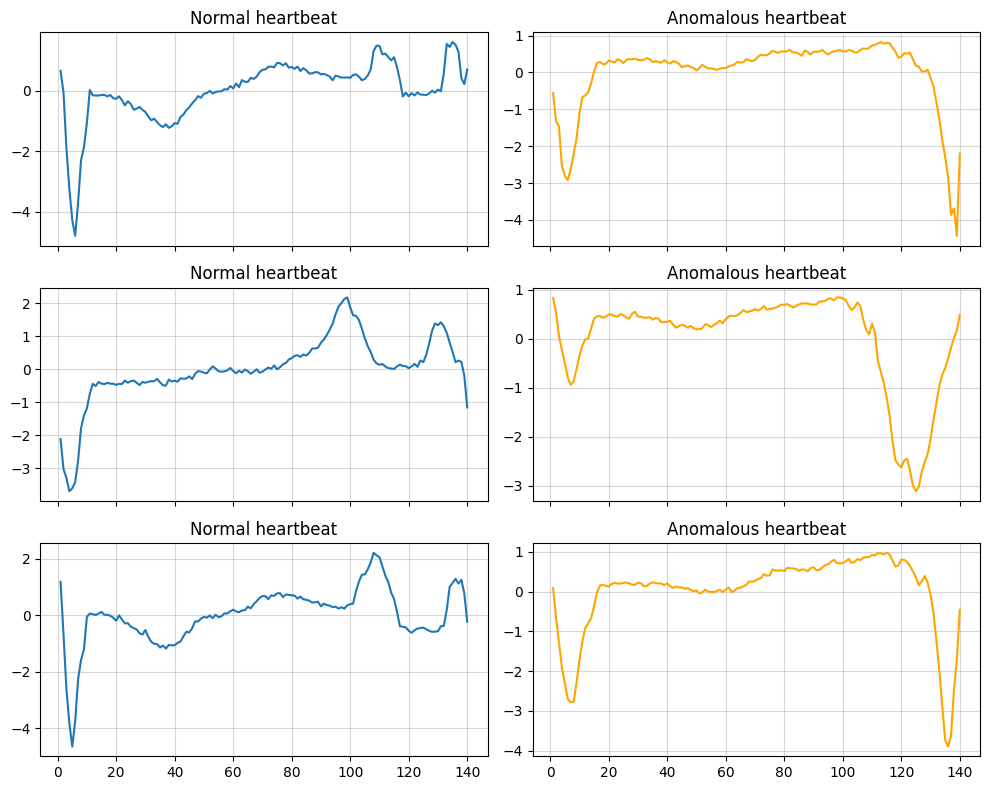

In [6]:
fig, axes = plt.subplots(3, 2, figsize=(10, 8), sharex=True)

for i in range(3):
    axes[i, 0].plot(normal_train.iloc[i])
    axes[i, 0].set_title(f'Normal heartbeat')
    axes[i, 0].grid(alpha=0.5)

    axes[i, 1].plot(anomaly_val.iloc[i], color='orange')
    axes[i, 1].set_title(f'Anomalous heartbeat')
    axes[i, 1].grid(alpha=0.5)

plt.tight_layout()
plt.show()

In [7]:
print(f"Mean value of normal heartbeats: {normal_train.values.mean():.2f}")
print(f"Standard deviation of normal heartbeats: {normal_train.values.std():.2f}")

Mean value of normal heartbeats: -0.00
Standard deviation of normal heartbeats: 1.00


The data have already zero mean and standard deviation equal to 1, so no further pre-processing is needed.

## 2 - Data Loading using the Dataset API

Use `tf.data.Dataset.from_tensor_slices` function giving as input the values of each reference dataframe. Remember that, since we are solving an anomaly detection task using an Autoencoder, we **do not** need labeled data, as the autoencoder will be trained *only* on normal data. Finally, to train the autoencoder, the dataset is transformed so that each input sample is paired with itself as the target, i.e., the model learns to reconstruct its own input. This is achieved by mapping the dataset to (x, x), producing suitable input–output pairs for autoencoder training.

### 2.1 - Dataset definition



In [8]:
def create_dataset(reference_df, batch_size, shuffle, repeat, cache_file=None):
    # Extract dataframes values
    ### START CODE HERE # (1 line)
    data = list(reference_df.values)
    ### END CODE HERE ###

    # Create a Dataset object
    ### START CODE HERE # (1 line)
    dataset = tf.data.Dataset.from_tensor_slices((data))
    ### END CODE HERE ###

    # Cache dataset
    if cache_file:
        dataset = dataset.cache(cache_file)

    # Shuffle
    if shuffle:
        dataset = dataset.shuffle(len(data))

    # Repeat the dataset indefinitely
    if repeat:
      dataset = dataset.repeat()

    # Correct input shape for the network
    dataset = dataset.map(lambda data: tf.expand_dims(data, 1))

    # Batch
    dataset = dataset.batch(batch_size=batch_size)

    # Prefetch
    dataset = dataset.prefetch(buffer_size=1)

    # Create suitable data format for AE
    ### START CODE HERE # (1 or 2 lines)
    dataset = dataset.map(lambda x: (x, x))
    ### END CODE HERE ###

    return dataset

### 2.2 - Dataset initialization
Now we can finally define our training, validation, and test datasets.

Remember that shuffling should be enabled only for the training set, while repeat should be disabled for test set.

In [9]:
batch_size = 64

train_n_dataset = create_dataset(normal_train,
                               batch_size=batch_size,
                               shuffle=True,
                               repeat = True,
                               cache_file=None)

val_n1_dataset = create_dataset(normal_val1,
                             batch_size=batch_size,
                             shuffle=False,
                             repeat = True,
                             cache_file=None)

val_n2_dataset = create_dataset(normal_val2,
                             batch_size=batch_size,
                             shuffle=False,
                             repeat = True,
                             cache_file=None)

test_n_dataset = create_dataset(normal_test,
                             batch_size=batch_size,
                             shuffle=False,
                             repeat = False,
                             cache_file=None)

val_a_dataset = create_dataset(anomaly_val,
                             batch_size=batch_size,
                             shuffle=False,
                             repeat = True,
                             cache_file=None)

test_a_dataset = create_dataset(anomaly_test,
                             batch_size=batch_size,
                             shuffle=False,
                             repeat = False,
                             cache_file=None)

# We need the steps only for those sets that are repeated, i.e., training and validation sets
train_steps = int(np.ceil(len(normal_train) / batch_size))
val1_steps = int(np.ceil(len(normal_val1) / batch_size))
val2_steps = int(np.ceil(len(normal_val2) / batch_size))
val_a_steps = int(np.ceil(len(anomaly_val) / batch_size))

 ## 3 - Autoencoder definition
 Here, you are free to define your autoencoder architecture.

 As a starting point, we propose the following AE, with the following encoder-decoder structure:

### Encoder

  - Input of shape (None, 140, 1)
  - Conv1D  with 16 channels, kernel size 5, stride 1, padding same, ELU activation
  - Conv1D  with 32 channels, kernel size 5, stride 1, padding same, ELU activation
  - Flatten
  - Dense layer to output the code, ELU activation

### Decoder

- Input of shape (None, code_size, )
- Dense with 140*32 units
- Reshape to add the channel dimension (obtain correct shape before applying convolutional layers)
- Transpose Conv1D with 32 channels, kernel size 5, stride 1, padding same, ELU activation
- Transpose Conv1D with 16 channels, kernel size 5, stride 1, padding same, ELU activation
- Transpose Conv1D with 1 channel, kernel size 1, stride 1, padding same, linear activation to output the reconstruction

Below, you find the structure to build the network model using the `Model` class but feel free to use the `Sequential` one instead.

In [10]:
def Encoder(input_shape, code_size):

    X_input = tf.keras.Input(input_shape)

    # Conv -> Conv -> Flatten
    ### START CODE HERE # (3 lines)
    X = tf.keras.layers.Conv1D(16, 5, strides=1, padding='same', activation='elu', name='conv1')(X_input)

    X = tf.keras.layers.Conv1D(32, 5, strides=1, padding='same', activation='elu', name='conv2')(X)

    X = tf.keras.layers.Flatten()(X)
    ### END CODE HERE ###

    # obtain the code
    ### START CODE HERE # (1 line)
    code = tf.keras.layers.Dense(code_size, activation='elu', name='dense_code')(X)
    ### END CODE HERE ###

    encoder = tf.keras.Model(inputs = X_input, outputs = code, name="Encoder")

    return encoder


def Decoder(code_size):

    code_input = tf.keras.Input((code_size,))

    ### START CODE HERE ### (4 lines)
    X = tf.keras.layers.Dense(140*32, activation='elu')(code_input)

    X = tf.keras.layers.Reshape((140, 32))(X)

    X = tf.keras.layers.Conv1DTranspose(32, 5, strides=1, padding='same', activation='elu', name='convT1')(X)

    X = tf.keras.layers.Conv1DTranspose(16, 5, strides=1, padding='same', activation='elu', name='convT2')(X)
    ### END CODE HERE ###

    # obtain reconstruction
    ### START CODE HERE ### (1 line)
    decoder_output = tf.keras.layers.Conv1DTranspose(1, 1, strides=1, padding='same', activation='linear', name='convT3')(X)
    ### END CODE HERE ###

    decoder = tf.keras.Model(inputs=code_input, outputs=decoder_output, name="Decoder")
    return decoder


def Autoencoder(input_shape, code_size):

    encoder = Encoder(input_shape, code_size)
    decoder = Decoder(code_size)

    X_input = tf.keras.Input(input_shape)
    # obtaining code from X_input
    ### START CODE HERE ### (1 line)
    code = encoder(X_input)
    ### END CODE HERE ###

    # obtaining decoded output from the code
    ### START CODE HERE ### (1 line)
    decoded_output = decoder(code)
    ### END CODE HERE ###

    autoencoder = tf.keras.Model(inputs=X_input, outputs=decoded_output, name="Autoencoder")
    return autoencoder, encoder, decoder

Create an instance of the model and compile it with Adam optimizer and Mean Absolute Error (MAE) loss.

**Note**: be aware that the function `Autoencoder()` returns 3 elements, i.e., the autoencoder, the encoder, and the decoder.

In [16]:
input_shape = (140, 1)
code_size = 64

### START CODE HERE # (2 lines)
autoencoder, encoder, decoder = Autoencoder(input_shape, code_size=code_size)
autoencoder.compile(optimizer="adam", loss="mae")
### END CODE HERE ###

autoencoder.summary()

Model: "Autoencoder"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_5 (InputLayer)      │ (None, 140, 1)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Encoder (Functional)            │ (None, 64)             │       289,472 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Decoder (Functional)            │ (None, 140, 1)         │       298,945 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 588,417 (2.24 MB)

 Trainable params: 588,417 (2.24 MB)

 Non-trainable params: 0 (0.00 B)

You can also print the encoder and decoder summary, to better inspect each module.

 ## 4 - Model training and testing
 ### 4.1 - Model training
 Now let's train the model for some epochs. Then plot the loss values and the accuracy during training. When fitting the model, remember to specify the train dataset, the number of epochs, the steps per epoch, the validation dataset, the number of validation steps, and the callbacks.

Here we use the early stopping [callback](https://www.tensorflow.org/api_docs/python/tf/keras/callbacks/EarlyStopping).

The train is very fast (even without using GPUs), so feel free to train different models!

In [17]:
# Train the model
num_epochs = 30

early_stop_callback = tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=5)

# Fit the model
### START CODE HERE ### (1 line)
history = autoencoder.fit(train_n_dataset,
                          epochs=num_epochs,
                          steps_per_epoch=train_steps,
                          validation_data=val_n1_dataset,
                          validation_steps=val1_steps,
                          callbacks=[early_stop_callback])
### END CODE HERE ###

# uncomment to save the model
#autoencoder.save('autoencoder.keras')

Epoch 1/30
35/35 ━━━━━━━━━━━━━━━━━━━━ 5s 75ms/step - loss: 0.3577 - val_loss: 0.1544
Epoch 2/30
35/35 ━━━━━━━━━━━━━━━━━━━━ 2s 71ms/step - loss: 0.1323 - val_loss: 0.1043
Epoch 3/30
35/35 ━━━━━━━━━━━━━━━━━━━━ 3s 74ms/step - loss: 0.0942 - val_loss: 0.0835
Epoch 4/30
35/35 ━━━━━━━━━━━━━━━━━━━━ 3s 74ms/step - loss: 0.0819 - val_loss: 0.0764
Epoch 5/30
35/35 ━━━━━━━━━━━━━━━━━━━━ 2s 44ms/step - loss: 0.0737 - val_loss: 0.0748
Epoch 6/30
35/35 ━━━━━━━━━━━━━━━━━━━━ 1s 41ms/step - loss: 0.0709 - val_loss: 0.0751
Epoch 7/30
35/35 ━━━━━━━━━━━━━━━━━━━━ 1s 42ms/step - loss: 0.0670 - val_loss: 0.0680
Epoch 8/30
35/35 ━━━━━━━━━━━━━━━━━━━━ 2s 63ms/step - loss: 0.0634 - val_loss: 0.0641
Epoch 9/30
35/35 ━━━━━━━━━━━━━━━━━━━━ 2s 70ms/step - loss: 0.0597 - val_loss: 0.0640
Epoch 10/30
35/35 ━━━━━━━━━━━━━━━━━━━━ 1s 39ms/step - loss: 0.0582 - val_loss: 0.0602
Epoch 11/30
35/35 ━━━━━━━━━━━━━━━━━━━━ 1s 40ms/step - loss: 0.0584 - val_loss: 0.0582
Epoch 12/30
35/35 ━━━━━━━━━━━━━━━━━━━━ 1s 40ms/step - loss: 0.0

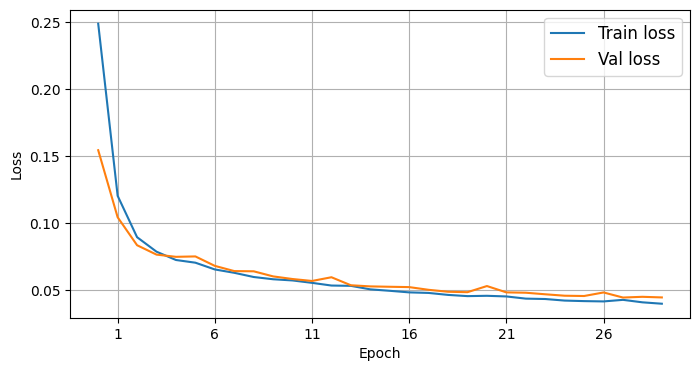

In [18]:
# Plot loss
plt.figure()
plt.plot(history.history['loss'], label='Train loss')
plt.plot(history.history['val_loss'], label='Val loss')
plt.legend()
plt.xticks(list(range(1, num_epochs + 1, 5)))
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.show()

 ## 5 - Threshold tuning

We will tune the threshold on the `val_n2_dataset + val_a_dataset`, choosing the value **maximing the F1-score**.



In [19]:
# this function implements the pipeline to compute the reconstruction errors on a dataset
def reconstruction_error_from_dataset(dataset, num_steps, model):
    errors = []

    for batch, _ in tqdm(dataset.take(num_steps)):
        batch = tf.cast(batch, tf.float32)
        recon = model(batch, training=False)
        batch_err = tf.reduce_mean(tf.square(batch - recon), axis=(1, 2))
        errors.append(batch_err.numpy())

    return np.concatenate(errors)

First of all, compute the errors on the `val_n1_dataset` using the function implemented above (remember to specify the correct number of steps) and look at the distribution.



100%|██████████| 5/5 [00:00<00:00, 24.82it/s]


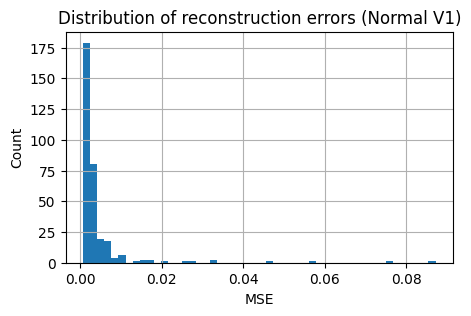

In [20]:
### START CODE HERE # (1 line)
err_v1 = reconstruction_error_from_dataset(val_n1_dataset, val1_steps, autoencoder)
### END CODE HERE ###

plt.figure(figsize=(5,3))
plt.hist(err_v1, bins=50)
plt.xlabel("MSE")
plt.ylabel("Count")
plt.title("Distribution of reconstruction errors (Normal V1)")
plt.show()

In the next cell, we compute the reconstruction errors on $Valid_{N2}$ and $Valid_{A}$, and we will concatenate them to obtain a single array called `errors`.

 We also create the arrays of the correct labels `y_true`, concatenating $|Valid_{N2}|$ zeros and $|Valid_{A}|$ ones (indeed, the correct class is identified with $0$, while the anomalous is identified with $1$).

In [21]:
err_v2 = reconstruction_error_from_dataset(val_n2_dataset, val2_steps, autoencoder)
err_a  = reconstruction_error_from_dataset(val_a_dataset, val_a_steps, autoencoder)

y_true = np.concatenate([np.zeros(len(err_v2)), np.ones(len(err_a))])

errors = np.concatenate([err_v2, err_a]) # errors on the set normal V2 + anomalous V

100%|██████████| 4/4 [00:00<00:00, 19.45it/s]


Now, to tune the threshold you have two possible ways:
- you can choose a set of possible threshold by looking at the error distribution on $Valid_{N1}$ (take a suitable interval and consider 50 values inside it - use `np.linspace()` to do that).
- or you can use *percentiles*. In particular, you can create a list of possible thresholds using the percentiles from the 90th to 99th.

Choose the method you prefer or, if you have time, test both of them.

Then, we will use each threshold to classify the anomalies starting from the errors:
- if the error is greather than the threshold, then predict $1$
- otherwise, predict class $0$.

Finally, we will compute the F1 score (use the function `f1_score` already imported) between `y_true` and `y_pred`.


In [22]:
# list to store the F1 of a specific threshold
f1_scores = []

### START CODE HERE #
thresholds = np.linspace(0.0, 0.02, 50)
### END CODE HERE ###

for thr in thresholds:
    ### START CODE HERE # (2 lines)
    y_pred = (errors > thr).astype(int)
    f1 = f1_score(y_true, y_pred)
    ### END CODE HERE ###
    f1_scores.append(f1)

Best threshold: 0.00939
Best F1 score: 0.9786


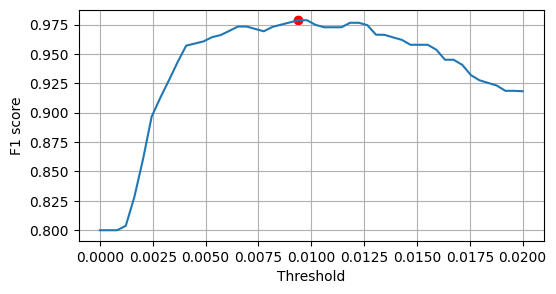

In [23]:
# obtain the thr that maximizes the F1
best_idx = np.argmax(f1_scores)
best_thr = thresholds[best_idx]
best_f1  = f1_scores[best_idx]

print(f"Best threshold: {best_thr:.5f}")
print(f"Best F1 score: {best_f1:.4f}")

# plot thresholds vs F1
plt.figure(figsize=(6,3))
plt.plot(thresholds, f1_scores)
plt.scatter(thresholds[best_idx], f1_scores[best_idx], color='red')
plt.xlabel("Threshold")
plt.ylabel("F1 score")
plt.show()

## 6 - Compute metrics on the test set

Now that we have found the best threshold, we can compute the metrics on the total test set $Test_N +Test_{A}$.

First of all, obtain the reconstructions on `test_n_dataset` and on `test_a_dataset` (use `model.predict()`).



In [24]:
### START CODE HERE # (2 lines)
X_test_n_recon = autoencoder.predict(test_n_dataset)
X_test_a_recon  = autoencoder.predict(test_a_dataset)
### END CODE HERE ###

5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 66ms/step
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step


In [25]:
# function to compute the reconstruction error
def reconstruction_error(dataset, recon):
    x = np.concatenate([x.numpy() for x,_ in dataset], axis=0)
    return np.mean((x - recon) ** 2, axis=(1, 2))

# compute the reconstruction error on each test set
err_test_n = reconstruction_error(test_n_dataset, X_test_n_recon)
err_test_a = reconstruction_error(test_a_dataset, X_test_a_recon)

In [26]:
y_true_test = np.concatenate([np.ones(len(err_test_a)), np.zeros(len(err_test_n)) ])

errors_test = np.concatenate([err_test_a, err_test_n])

y_pred_test = (errors_test > best_thr).astype(int)

acc  = accuracy_score(y_true_test, y_pred_test)
prec = precision_score(y_true_test, y_pred_test)
rec  = recall_score(y_true_test, y_pred_test)
f1   = f1_score(y_true_test, y_pred_test)

print(f"Accuracy : {acc:.4f}")
print(f"Precision: {prec:.4f}")
print(f"Recall   : {rec:.4f}")
print(f"F1 score : {f1:.4f}\n")

print("\nClassification Report:")
print(classification_report(y_true_test, y_pred_test, target_names=["Normal", "Anomaly"]))

Accuracy : 0.9723
Precision: 0.9951
Recall   : 0.9728
F1 score : 0.9838


Classification Report:
              precision    recall  f1-score   support

      Normal       0.85      0.97      0.90       292
     Anomaly       1.00      0.97      0.98      1873

    accuracy                           0.97      2165
   macro avg       0.92      0.97      0.94      2165
weighted avg       0.98      0.97      0.97      2165



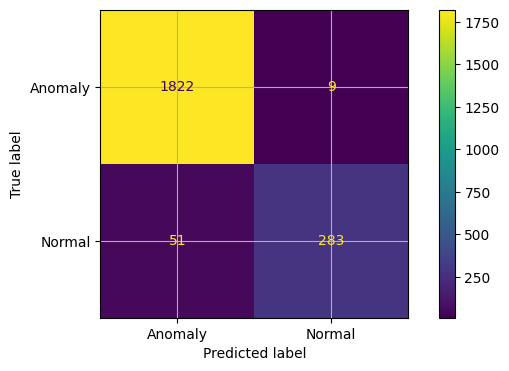

In [27]:
# Compute confusion matrix
cm = confusion_matrix(np.where(y_pred_test==1, 0, 1), np.where(y_true_test==1, 0, 1))
labels = ["Anomaly", "Normal"]

dist = ConfusionMatrixDisplay(confusion_matrix = cm, display_labels = ['Anomaly', 'Normal'])
dist.plot()

## 7 - One-class Support Vector Machine (OC-SVM)

As seen during the course classes, we can perform anomaly detection leveraging Support Vector Machines. One-class Support Vector Machine (OC-SVM) enables the usage of data only from the normal class, a precious resource to avoid the expensive efforts often required to obtain labeled training data for the anomaly class.

As you may know, the main idea of SVM for classification tasks is to maximize the distance of the separating hyperplane (the so called *margin*) from both classes. However, in this context we have the data from one class only, and margin maximization has infinite solutions due to the algorithm being able to adjust the offset value of the hyperplane to accomodate any change in the margin. To workaround the problem, an algorithm that maximizes both the margin and the distance from the origin is defined; this formulation provides a unique solution, and has the following form:

\begin{align*}
\underset{w, b}{\text{min}} & \frac{1}{2} || w ||^{2}_{2} - \rho + \frac{1}{\nu N} \sum^{N}_{i = 1} \xi_{i} \\
\text{s.t.} \ & w^{T}x_{i} \geq \rho + \xi_{i}, \ \forall i \\
& \xi_{i} \geq, 0 \ \forall i
\end{align*}

the dual problem is:

\begin{align*}
\underset{\alpha}{\text{min}} \quad & \frac{1}{2} \sum^{N}_{i, j = 1} \alpha_{i} \alpha_{j} x_{i}^{T} x_{j} \\
\text{s.t.} \quad & \sum^{N}_{i = 1} \alpha_{i} = 1 \\
& 0 \leq \alpha_{i} \leq \frac{1}{\nu N}, \quad \forall i = 1, \dots, N
\end{align*}

and the optimal value for $w, \rho$ are:

\begin{equation*}
w^{*} = \sum^{N}_{i = 1} \alpha^{*}_{i} x_{i}
\end{equation*}

\begin{equation}
\rho^{*} = (w^{*})^{T} x_{k}, \quad \text{for any } x_{k} \text{ such that } 0 < \alpha^{*}_{k} < \frac{1}{\nu N}.
\end{equation}

New points are classified according to the function:

\begin{equation*}
f(x) = sign((w^{*})^{T}x - \rho^{*})
\end{equation*}

Here, we obtain a tight margin by minimizing $ ||w||^{2}_{2} $ leveraging the term $\rho$, that pushes the hyperplane away from the origin. The result is an hyperplane that is perpendicular to the vector generated by a convex combination of the so called *support vectors* (the vectors for which the $\alpha$ coefficients are not zero). The parameter $\nu$ determines tolerance for misclassifications.

Now, let's try to fit a one-class support vector to our data.

In [28]:
# import the library
from sklearn.svm import OneClassSVM

OC-SVM can be easily implemented using `scikit-learn`, which contains built-in functions for that; however, as shown in the optimization problem, the model requires all the data at the same time to compute the optimal values (there are ways to approximate the result using SGD - see the [documentation](https://scikit-learn.org/stable/auto_examples/linear_model/plot_sgdocsvm_vs_ocsvm.html)), so we cannot use directly the dataset defined with TensorFlow Dataset API.

You can find scikit-learn documentation on OC-SVM [here](https://scikit-learn.org/stable/modules/generated/sklearn.svm.OneClassSVM.html).

OC-SVM implementation in scikit-learn labels normal class as 1.

In [29]:
mask = reference_df.iloc[:, 0] == 1

# create normal and anomalous datasets for OC-SVM
svm_normal_df = reference_df[mask]
svm_anomaly_df = reference_df[~mask]

# split normal dataset into train and test
svm_train_df, svm_normal_test_df = train_test_split(svm_normal_df,
                                                  test_size=0.15, random_state=42)

The commented code below splits the dataset to obtain also a validation set, if you want to perform hyper-parameter selection.

In [30]:
### ------------------------------------------------------------------------------- ###
### Uncomment this part of code only if you want to perform grid search
### for hyperparameters selection at the end of the notebook.
### ------------------------------------------------------------------------------- ###


# svm_train_df, svm_normal_val_df = train_test_split(svm_train_df,
#                                               test_size=0.1, random_state=42)
# svm_anomaly_test_df, svm_anomaly_val_df = train_test_split(svm_anomaly_df,
#                                               test_size=0.15, random_state=42)

# train_labels = svm_train_df.iloc[:, 0]
# val_labels = pd.concat([svm_anomaly_val_df.iloc[:, 0], svm_normal_val_df.iloc[:, 0]])
# test_labels = pd.concat([svm_normal_test_df.iloc[:, 0], svm_anomaly_test_df.iloc[:, 0]])

# val_labels = np.where(val_labels == 1, val_labels, 0)
# test_labels = np.where(test_labels == 1, test_labels, 0)

# train_list = svm_train_df.iloc[:, 1:]
# val_list = pd.concat([svm_anomaly_val_df.iloc[:, 1:], svm_normal_val_df.iloc[:, 1:]])
# test_list = pd.concat([svm_normal_test_df.iloc[:, 1:], svm_anomaly_test_df.iloc[:, 1:]])


### ------------------------------------------------------------------------------- ###
### Comment the code below only if you want to perform grid search
### ------------------------------------------------------------------------------- ###

train_labels = svm_train_df.iloc[:, 0]
test_labels = pd.concat([svm_anomaly_df.iloc[:, 0], svm_normal_test_df.iloc[:, 0]])

test_labels = np.where(test_labels == 1, test_labels, 0)


train_list = svm_train_df.iloc[:, 1:]
test_list = pd.concat([svm_anomaly_df.iloc[:, 1:], svm_normal_test_df.iloc[:, 1:]])

### 7.1 - Linear OC-SVM

In the upcoming cells we will fit a simple *linear OC-SVM*; however, in general,linear OC-SVM might not work well, as they require specific conditions. Here, we consider a case where **no or few misclassification are allowed** (i.e., low $\nu$), but the logic holds similar for the general case:

- The anomaly class and the normal class data should be linearly separable and, furthermore, the anomaly class should be located between the normal class and the origin, or the origin should be located between the normal class and the anomaly class. In any other configuration, at test time the anomaly and the normal data would be on the same side of the separating hyperplane.

- The normal data points should be separated from the origin, otherwise the algorithm won't be able to separate the data from the origin.

It is clear that the first condition is not always met and the second one prevents centering and standardization of the data points, preventing the use of, for example, PCA or algorithms that tend to push data toward the origin, such as $\beta$-Variational Autoencoders.

Let's see what happens if we center the data and try to fit a linear OC-SVM.

In [31]:
# compute mean and standard deviation of training data (feature wise)

mu = np.mean(train_list, axis = 0)
sigma = np.std(train_list, axis = 0)

centered_training_data = (train_list - mu) / sigma

In [32]:
# nu is set to a small value to increase the penalty for errors.
nu = 0.00001

oc_svm = OneClassSVM(kernel = 'linear', nu = nu)

oc_svm.fit(centered_training_data)

y_raw = oc_svm.decision_function(centered_training_data)

# converting raw score to prediction
y = (y_raw >= 0).astype(int)

print('Train accuracy: ', round(accuracy_score(train_labels, y), 4))

Train accuracy:  0.5994


As you will see, shifting the data changes the result.

In [63]:
center = 5

centered_training_data = (train_list - mu + center) / sigma

In [33]:
# nu is set to a small value to increase the penalty for errors.
nu = 0.00001

oc_svm = OneClassSVM(kernel = 'linear', nu = nu)

oc_svm.fit(centered_training_data)

y_raw = oc_svm.decision_function(centered_training_data)

# converting raw score to prediction
y = (y_raw >= 0).astype(int)

print('Train accuracy: ', round(accuracy_score(train_labels, y), 4))

Train accuracy:  0.5994


The algorithm cannot put the data on the correct side of the hyperplane when data are centered on the origin. However, rather surprinsigly, the linear OC-SVM performs just fine on the original, non-centered data and is able to generalize to the test set; this might not always be the case, even when data are linearly separable.

In [34]:
batch_size = 32

train_dataset = create_dataset(train_list,
                               batch_size=batch_size,
                               shuffle = False, repeat = False)
# val_dataset = create_dataset(val_list,
#                              batch_size=batch_size,
#                              shuffle = False, repeat = False) ### Uncomment if you intend to perform grid search at the end of the notebook
test_dataset = create_dataset(test_list,
                             batch_size=batch_size,
                             shuffle = False, repeat = False)

In [35]:
train_list = encoder.predict(train_dataset)
# val_list = encoder.predict(val_dataset) ### Uncomment if you intend to perform grid search at the end of the notebook
test_list = encoder.predict(test_dataset)

78/78 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step
79/79 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step


As anticipated, we will use the code of the previously trained autoencoder as the input of the OC-SVM. With this specific dataset, the OC-SVM is easily fitted to the original input vector anyway, but, at times, using an autoencoder as a transformation step can help improving performances. This is useful in many ways, as some kernels (e.g., RBF) may struggle with high dimensional data, while just using the difference between the distributions of the autoencoder reconstruction error might not suffice; moreover, there exists some specific types of autoencoders that might be able to structure the latent space in a way that make easier for the OC-SVM to correctly separate the normal class.

## 8 - Kernel Trick and Kernels

When classes have more complex boundaries we need to craft transformations that provide a new (usually higher dimensional) representation of the data. The new representation can be, however, both hard to obtain and can require unfeasible computational or storage resources; for such scenario, we can leverage the so called *kernel trick*. The kernel trick can be applied to any algorithm that makes use of the input only inside scalar products between the data features vectors, but it is particularly used with SVM and its variants.

When such condition applies to our algorithm, we can substitute the result of such product with a function defined on the original input space that yields the same result as the dot product performed on the transformed (higher dimensional) space. Given a transformation $\phi(\cdot): \mathbb{R}^{n} \rightarrow \mathbb{R}^{d}, \ n \in \mathbb{N}^{+}, \ d \in \mathbb{N}^{+} \cup \{\infty\}$, the function used is the so called kernel function:

\begin{equation*}
K ( x_{i}, x_{j} ) = \phi(x_{i}) \cdot \phi(x_{j}).
\end{equation*}

Substituting it, the dual problem becomes:

\begin{align*}
\underset{\alpha}{\text{min}} \quad & \frac{1}{2} \sum^{N}_{i, j = 1} \alpha_{i} \alpha_{j} K ( x_{i}, x_{j} ) \\
\text{s.t.} \quad & \sum^{N}_{i = 1} \alpha_{i} = 1 \\
& 0 \leq \alpha_{i} \leq \frac{1}{\nu N}, \quad \forall i = 1, \dots, N.
\end{align*}

Crucially, new samples are classified using the score:

\begin{equation*}
\text{score}(\phi(x_{new})) = w^{*} \cdot \phi(x_{new}) - \rho^{*},
\end{equation*}

and the score can be computed using the kernel function (remember that $w^{*} = \sum_{i : \alpha_{i} > 0} \alpha_{i} \phi(x_{i})$):

\begin{equation*}
\sum_{i:\,\alpha_{i} > 0} \alpha_{i} \phi(x_{i}) \cdot \phi(x_{new}) - \rho^{*} = \sum_{i:\,\alpha_{i} > 0} \alpha_{i} K ( x_{i}, x_{new} ) -\rho^{*}.
\end{equation*}

When we can write the result of $K( \cdot, \cdot )$ using the data vectors in the original input space, we do not actually have to apply any transformation to our data.

The effectiveness of the kernel trick become apparent when we need to apply transformations ($\phi( \cdot )$) that are either very expensive or cannot be computed as the new feature space is infinite dimensional (e.g. radial basis kernel). In fact, we just need to compute $K$ between the support vectors and the new data to determine how they are classified. The sparseness of the $\alpha$ coefficients allows to increase inference efficiency and decrease the storage required to compute the weights.

### 8.1 - Radial Basis Function (RBF)
RBF is usually the first choice kernel in SVM, especially when we have no prior knowledge of how the data should behave. The kernel function is defined as:

\begin{equation*}
K (x,y) = e^{ - \gamma || x - y ||_{2}^{2}},
\end{equation*}

where $\gamma = \frac{1}{2 \sigma}$ is an hyperparameter.

The kernel maps the data into an infinite dimensional space, in which the norm of any vector is $1$ ($K (x,y) = e^{0} = 1$). The SVM with RBF kernel is a universal approximator and can model any function, provided the right hyperparameters and the correct distribution of support vectors; however, the tuning of $\gamma$ is not always easy.

The RBF kernel is a good choice for anomaly detection as the kernel function is based on distance, and, once the support vectors are found by the algorithm, the class is determined by the distance from such support vectors. This provides the algorithm with the ability to basically wrap the decision boundaries more or less tightly around the clouds of normal data points, depending on the hyperparameters choice. This can be often a good assumption in situation where we don't know how the data are distributed in the input space.

In [36]:
gamma = 'auto'
nu = 0.1

# implement OC-SVM with RBF kernel
oc_svm = OneClassSVM(kernel = 'rbf', gamma = gamma, nu = nu)

oc_svm.fit(train_list)

y_raw = oc_svm.decision_function(train_list)

y = (y_raw >= 0).astype(int)

print('Train accuracy: ', round(accuracy_score(train_labels, y), 4))

Train accuracy:  0.9


In [37]:
y_raw = oc_svm.decision_function(test_list)

y = (y_raw >= 0).astype(int)

In [38]:
accuracy = accuracy_score(test_labels, y)

precision, recall, f_1, _ = precision_recall_fscore_support(test_labels, y)

print('Accuracy: ', round(accuracy, 4))
print('Precision: ', round(precision[1], 4))
print('Recall: ', round(recall[1], 4))

Accuracy:  0.9841
Precision:  0.9807
Recall:  0.9269


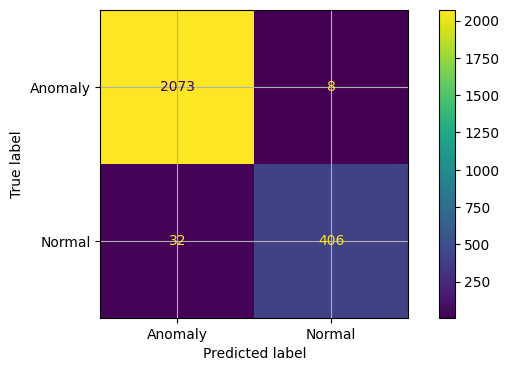

In [39]:
confusion_m = confusion_matrix(test_labels, y)

dist = ConfusionMatrixDisplay(confusion_matrix = confusion_m, display_labels = ['Anomaly', 'Normal'])
dist.plot()

### 8.2 - Polynomial Kernel

Polynomial kernel use the function $K ( x, y ) = (\gamma x^{T} \cdot y + r)^{d}$, where $r, \gamma, d$ are hyperparameters. This kernel can model complex data relations and non linear boundaries by increasing the degree of the polynomial;however, the kernel might become numerically less stable as the polynomial degree increases, and is less versatile than the rbf kernel, while requiring more tuning to wrap around data clusters of complex shape. Usually, rbf kernel is the base choice, while the polynomial kernel is used in presence of prior knowledge about the data or interaction between the features.

In [52]:
gamma = 'auto'
nu = 0.1

# you can also change the degree of the polynomial
# degree = 3

oc_svm = OneClassSVM(kernel = 'poly', gamma = gamma, nu = nu)

oc_svm.fit(train_list)

y_raw = oc_svm.decision_function(train_list)

y = (y_raw >= 0).astype(int)

print('Train accuracy: ', round(accuracy_score(train_labels, y),4))

Train accuracy:  0.8956


In [50]:
y_raw = oc_svm.decision_function(test_list)

y = (y_raw >= 0).astype(int)

In [51]:
accuracy = accuracy_score(test_labels, y)


precision, recall, f_1, _ = precision_recall_fscore_support(test_labels, y)

print('Accuracy: ', round(accuracy, 4))
print('Precision: ', round(precision[1], 4))
print('Recall: ', round(recall[1], 4))

Accuracy:  0.9782
Precision:  0.9799
Recall:  0.8927


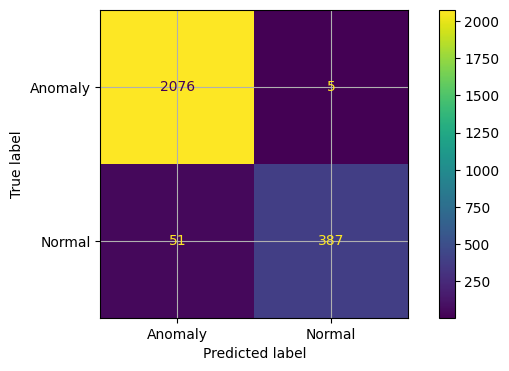

In [74]:
confusion_m = confusion_matrix(test_labels, y)

dist = ConfusionMatrixDisplay(confusion_matrix = confusion_m, display_labels = ['Anomaly', 'Normal'])
dist.plot()

### Sigmoid Kernel

The Sigmoid kernel uses the function $K(x, y) = \tanh(\gamma x^T \cdot y + r)$, where $\gamma$ and $r$ are hyperparameters. This kernel is not positive semi-definite for all parameter values, meaning it is not a valid kernel in every configuration and can be more difficult to tune than the RBF kernel. Usually, the RBF kernel is the preferred default for non-linear tasks, while the sigmoid kernel is used when there is need to approximate the activation dynamics of neural networks.

In [44]:
gamma = 'auto'
nu = 0.1

# you can also change the degree of the polynomial
# degree = 3

oc_svm = OneClassSVM(kernel = 'sigmoid', gamma = gamma, nu = nu)

oc_svm.fit(train_list)

y_raw = oc_svm.decision_function(train_list)

y = (y_raw >= 0).astype(int)

print('Train accuracy: ', round(accuracy_score(train_labels, y),4))

Train accuracy:  0.9


In [46]:
y_raw = oc_svm.decision_function(test_list)

y = (y_raw >= 0).astype(int)

In [47]:
accuracy = accuracy_score(test_labels, y)


precision, recall, f_1, _ = precision_recall_fscore_support(test_labels, y)

print('Accuracy: ', round(accuracy, 4))
print('Precision: ', round(precision[1], 4))
print('Recall: ', round(recall[1], 4))

Accuracy:  0.9714
Precision:  0.9159
Recall:  0.9201


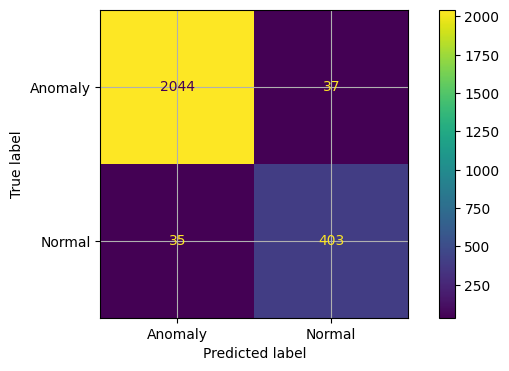

In [48]:
confusion_m = confusion_matrix(test_labels, y)

dist = ConfusionMatrixDisplay(confusion_matrix = confusion_m, display_labels = ['Anomaly', 'Normal'])
dist.plot()

In case you need to perform a search over the hyperparameters space, you can do so by using the grid search algorithm in the next cell. The actual hyperparameters used in the previous cells were obtained through a telescopic search, which is an iterative grid search, that, at every re-initialization, searches in finer detail a restriction of the original search space.

Remember to uncomment the part of the cell to instantiate the validation data.

In [79]:
# # Uncomment to perform grid search


# param_grid = {
#     'gamma': ['auto', 'scale', 0.1, 0.01, 0.001],
#     'nu': [0.1, 0.01, 0.0001],
#     # 'degree': [2, 3, 4]
# }


# kernel = 'rbf'

# max_f1 = 0
# best_gamma = None
# best_nu = None

# for gamma in param_grid['gamma']:
#     for nu in param_grid['nu']:
#       # for degree in param_grid['degree']:

#           oc_svm = OneClassSVM(kernel = kernel, gamma = gamma, nu = nu) # degree = degree

#           oc_svm.fit(train_list)

#           y_raw = oc_svm.decision_function(val_list)

#           y = (y_raw >= 0).astype(int)

#           f1 = f1_score(val_labels, y)

#           print('f1 score: ', f1)
#           print('Gamma: ', gamma)
#           print('Nu: ', nu)
#           # print('Degree: ', degree)

#           if f1 > max_f1:
#               max_f1 = f1
#               best_gamma = gamma
#               best_nu = nu
#               # best_degree = degree

In [80]:
# oc_svm = OneClassSVM(kernel = kernel, gamma = best_gamma, nu = best_nu) # degree = best_degree

# oc_svm.fit(train_list)

In [81]:
# y_raw = oc_svm.decision_function(test_list)

# y = (y_raw >= 0).astype(int)

In [47]:
# accuracy = accuracy_score(test_labels, y)


# precision, recall, f_1, _ = precision_recall_fscore_support(test_labels, y)

#print('Accuracy: ', round(accuracy, 4))
#print('Precision: ', round(precision[1], 4))
#print('Recall: ', round(recall[1], 4))